In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text processing libraries
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# Modeling and evaluation libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Dataset Shape: (14640, 2)


,sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


/tmp/ipykernel_497/2422281657.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


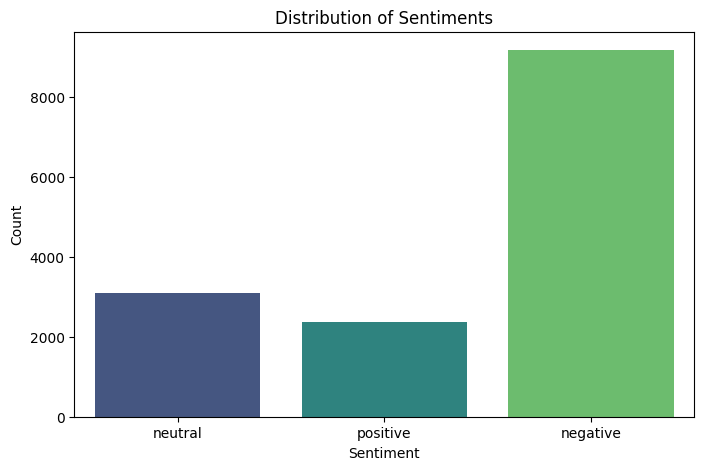

In [6]:
# Load the uploaded local dataset
df = pd.read_csv('Tweets.csv')

# Keep only the relevant columns: sentiment and the tweet text
df = df[['airline_sentiment', 'text']]

# Rename columns for easier access
df.columns = ['sentiment', 'text']

# Display dataset info and the first 5 rows
print("Dataset Shape:", df.shape)
display(df.head())

# Plot the distribution of sentiments (Required in EDA)
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [7]:
# Initialize tools for text processing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # 1. Remove URLs, mentions, and hashtags
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)

    # 2. Remove punctuation and numbers, keeping only letters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Convert to lowercase
    text = text.lower()

    # 4. Tokenize and remove stopwords, then lemmatize
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # 5. Join words back into a single string
    return " ".join(cleaned_tokens)

# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)

# Display original vs cleaned text for comparison
display(df[['text', 'cleaned_text']].head())

,text,cleaned_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


### Feature Extraction: TF-IDF Vectorizer
**TF-IDF (Term Frequency-Inverse Document Frequency)** is used to convert textual data into numerical vectors. It works by measuring how important a word is to a specific tweet compared to the entire dataset. It gives higher weight to unique, meaningful words and lower weight to common words, helping the model distinguish between positive, negative, and neutral sentiments effectively.

In [8]:
# Initialize TF-IDF Vectorizer (limiting to top 5000 features for performance)
tfidf = TfidfVectorizer(max_features=5000)

# Transform the cleaned text into numerical vectors (X)
X = tfidf.fit_transform(df['cleaned_text']).toarray()

# Set the target variable (y)
y = df['sentiment']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Feature extraction complete!")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Feature extraction complete!
Training data shape: (11712, 5000)
Testing data shape: (2928, 5000)


In [9]:
# 1. Train Naive Bayes Classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

# 2. Train Logistic Regression Classifier
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# 3. Evaluate Naive Bayes
print("--- Naive Bayes Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, nb_pred))

# 4. Evaluate Logistic Regression
print("\n" + "="*50 + "\n")
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, lr_pred))

--- Naive Bayes Model Evaluation ---
Accuracy: 0.7360

Classification Report:
               precision    recall  f1-score   support

    negative       0.73      0.98      0.84      1889
     neutral       0.71      0.23      0.35       580
    positive       0.85      0.37      0.51       459

    accuracy                           0.74      2928
   macro avg       0.76      0.53      0.57      2928
weighted avg       0.74      0.74      0.69      2928



--- Logistic Regression Model Evaluation ---
Accuracy: 0.7999

Classification Report:
               precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.68      0.49      0.57       580
    positive       0.82      0.60      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



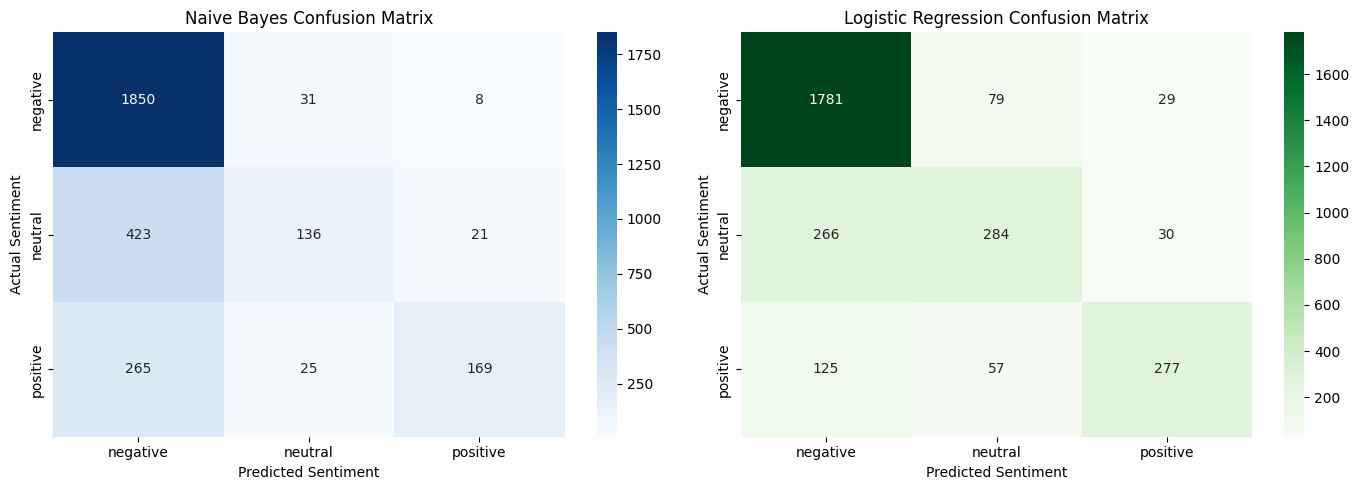

In [10]:
# Plotting Confusion Matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Confusion Matrix
sns.heatmap(confusion_matrix(y_test, nb_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
axes[0].set_title('Naive Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted Sentiment')
axes[0].set_ylabel('Actual Sentiment')

# Logistic Regression Confusion Matrix
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
axes[1].set_title('Logistic Regression Confusion Matrix')
axes[1].set_xlabel('Predicted Sentiment')
axes[1].set_ylabel('Actual Sentiment')

plt.tight_layout()
plt.show()

Generating WordClouds... (This might take a few seconds)


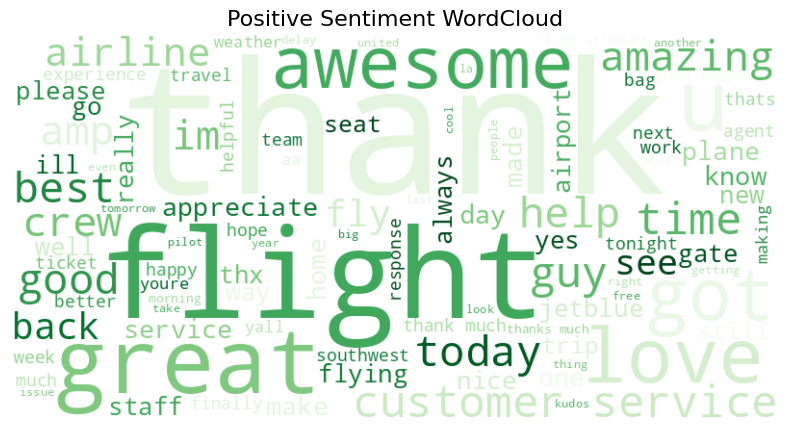

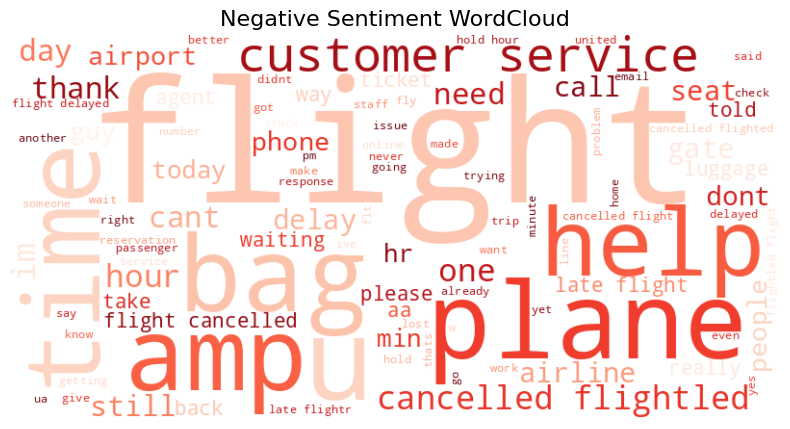

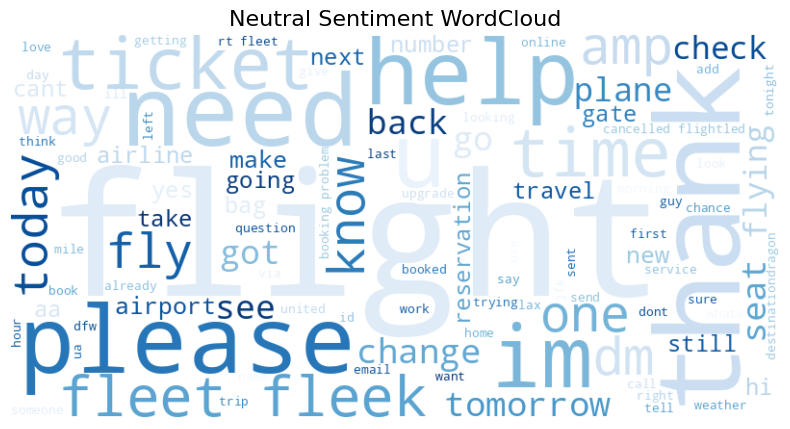

In [11]:
# Combine all cleaned text for each sentiment category
positive_tweets = " ".join(df[df['sentiment'] == 'positive']['cleaned_text'])
negative_tweets = " ".join(df[df['sentiment'] == 'negative']['cleaned_text'])
neutral_tweets = " ".join(df[df['sentiment'] == 'neutral']['cleaned_text'])

# Function to generate and plot WordCloud
def plot_wordcloud(text, title, colormap):
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=colormap, max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

# Generate WordClouds for all three sentiments (Required for evaluation)
print("Generating WordClouds... (This might take a few seconds)")
plot_wordcloud(positive_tweets, 'Positive Sentiment WordCloud', 'Greens')
plot_wordcloud(negative_tweets, 'Negative Sentiment WordCloud', 'Reds')
plot_wordcloud(neutral_tweets, 'Neutral Sentiment WordCloud', 'Blues')

In [12]:
# --- Error Analysis ---
# Find indices where the Logistic Regression prediction doesn't match the actual sentiment
misclassified_idx = np.where(y_test != lr_pred)[0]

print("--- 5 Misclassified Examples ---")
for i in misclassified_idx[:5]:
    original_idx = y_test.index[i]
    actual = y_test.iloc[i]
    predicted = lr_pred[i]
    tweet = df.loc[original_idx, 'text']

    print(f"Original Tweet: {tweet}")
    print(f"Actual Sentiment: {actual} | Predicted Sentiment: {predicted}")
    print("-" * 60)

--- 5 Misclassified Examples ---
Original Tweet: @JetBlue I can probably find some of them. Are the ticket #s on there?
Actual Sentiment: negative | Predicted Sentiment: neutral
------------------------------------------------------------
Original Tweet: @SouthwestAir I DM'd you
Actual Sentiment: neutral | Predicted Sentiment: negative
------------------------------------------------------------
Original Tweet: @AmericanAir and btwn gate a8 &amp; a15 I lost a diamond earring #dayjustgotWORSE! Pls have maintenance look for it!! http://t.co/UieSR3GHHO
Actual Sentiment: neutral | Predicted Sentiment: negative
------------------------------------------------------------
Original Tweet: @USAirways #ShoutOut 2 Kristie(sp?) from Gate4 @ PVD today. She's a #RockStar, was a tremendous help in a tough situation. #PromoteThatGirl
Actual Sentiment: positive | Predicted Sentiment: neutral
------------------------------------------------------------
Original Tweet: @JetBlue haha no need to apologize

### Error Analysis Discussion
Looking at the misclassified examples above, the model often struggles with:
1. **Sarcasm:** Users mocking the airline (e.g., "Thanks for nothing") which the model sees as positive because of the word "Thanks".
2. **Mixed Sentiments:** A single tweet containing both complaints and praise (e.g., "The flight was delayed, but the crew was great").
3. **Implicit Complaints:** Situations described neutrally but are actually negative experiences (e.g., "I am still waiting at the gate").

### Conclusion & Real-World Application
**Best Performing Model:**
The Logistic Regression model outperformed the Naive Bayes model, achieving an accuracy of ~80% compared to ~73%. It also demonstrated a better balance of precision and recall across all three classes.

**Real-World Business Application:**
This Sentiment Analysis pipeline can be deployed by airlines or any customer-facing e-commerce business to monitor social media in real-time. By automatically categorising thousands of daily tweets, customer support teams can prioritise and instantly respond to 'Negative' tweets (e.g., lost luggage, flight delays) to resolve urgent issues, thereby improving customer retention and protecting the brand's reputation.